# Introduction

This project explores commonsense question answering using the CommonsenseQA dataset, which contains multiple-choice questions. 

We compare three approaches: 
1. Randomly initialized Transformer model.
2. Pretrained Transformer model fine-tuned on our task
3. Large language model (LLM) with prompt engineering. 

By evaluating these models' performance on the same dataset, we aim to understand how initialization, pretraining, and model scale affect reasoning capabilities in natural language understanding tasks. 

This notebook documents our experimental setup, implementation details, and analysis of results.

## Dataset

[CommonsenseQA](https://huggingface.co/datasets/tau/commonsense_qa) is a multiple-choice question answering dataset that requires common sense knowledge to select the correct answer from five choices.

Here's an example:

**Question:**
The sanctions against the school were a punishing blow, and they seemed to what the efforts the school had made to change?

**Choices:**
- A. ignroe
- B. enforce
- C. authoritarian
- D. yell at
- E. avoid

# Setup

In this section, I configure the environment necessary for implementing and evaluating the three models.

As I used both MacOS and Windows during project work, the notebook is implemented to work for both systems.

## Configuration

This section controls the configuration for the cell executions of this notebook.

| **Variable**                 | **Description**     | 
|------------------------------|--------------------------|
| `RUN_SWEEP`                  | If `true` sweeps will be started instead of single training run if training is enabled for transformer         |
| `RUN_RANDOM_TRANSFORMER`     | Whether to run the training for the **random** transformer or not         | 
| `RUN_PRETRAINED_TRANSFORMER` | Whether to run the training for the **pretrained** transformer or not        |


In [1]:
RUN_RANDOM_TRANSFORMER = True
RUN_PRETRAINED_TRANSFORMER = True

RUN_SWEEP = False

## Installation

To run the notebook I used `python 3.12.10`. 

In [2]:
import platform

%pip install numpy==2.1.2
%pip install pandas==2.2.3
%pip install matplotlib==3.10.1

if platform.system() == 'Darwin':
    # macos
    %pip install torch==2.7.0 torchaudio==2.7.0 torchvision==0.22.0
else:
    # windows or linux with cuda
    %pip install torch==2.7.0+cu128 torchaudio==2.7.0+cu128 torchvision==0.22.0+cu128

%pip install huggingface-hub==0.31.1
%pip install datasets==3.6.0

%pip install transformers==4.51.3

%pip install tqdm==4.67.1

%pip install wandb==0.19.11
%pip install nbformat==5.10.4

%pip install scikit-learn==1.6.1

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports

This section contains all the imports that are required in this notebook and gives a brief overview which packages are being used.

In [3]:
import os
import gc
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

from huggingface_hub import hf_hub_download
from datasets import load_dataset

from transformers import (
    RobertaConfig, 
    RobertaForMultipleChoice, 
    RobertaTokenizer,
    AutoTokenizer,
    AutoModelForSeq2SeqLM, 
    get_linear_schedule_with_warmup
)

from sklearn.metrics import accuracy_score, confusion_matrix

from tqdm.auto import tqdm

import wandb


We also want to use the GPU to achieve **faster computations**, which is why we define **cuda** (for Windows and Linux) or **mps** (for macOS) if available.

In [4]:
device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
print(f'Using device for computations: {device}')

Using device for computations: cuda


## Seed

Setting a fixed random seed ensures **reproducibility** of results across runs. 

We set the seed for NumPy and PyTorch random number generators to ensure that random operations like weight initialization and data shuffling produce the same results each time the notebook is executed.

In [5]:
SEED = 5

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED) 

## Experiment Tracking

[Weights and Biases](https://wandb.ai/site/) is a machine learning experiment tracking and visualization platform that helps track, compare, and optimize models.

The dashboard is available here: [Project 2 - Transformer](https://wandb.ai/timon-schmid-hochschule-luzern/hslu-nlp-commonsense_qa?nw=k2w45nzhefj)

In [6]:
wandb.login()

wandb: Currently logged in as: timon-schmid (timon-schmid-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

### Wandb Helpers

The function `save_model_for_wandb` provides system independent model saving for wandb logging.

In [7]:
def save_model_for_wandb(model, model_name):
    model_path = os.path.join(os.getcwd(), f"{model_name}_model.pt")
    torch.save(model.state_dict(), model_path)
    
    artifact = wandb.Artifact(f"{model_name}_model", type="model")
    artifact.add_file(model_path)
    wandb.log_artifact(artifact)
    
    return model_path

### Sweep

Next to manual hyperparameter tuning, I decided to use sweep to find the perfect parameters more efficient.

But before defining the parameter ranges I had to find some parameters by hand to reduce the amount of parameters that should be tuned:
| **Parameter**               | **Value** | **Reasoning**                                                      |
|-----------------------------|-----------|--------------------------------------------------------------------|
| `batch_size`                | 32        | Maximizes GPU memory utilization during training                   |
| `num_epochs`                | 25        | Estimated based on preliminary manual runs                         |
| `early_stopping_patience`   | 3         | Minimizes training duration by stopping early after stagnation     |

The other parameter ranges were chosen with the following reasoning:
| **Parameter**                 | **Values**     | **Reasoning**                                                      |
|-------------------------------|----------------|--------------------------------------------------------------------|
| `learning_rate`               | 1e-4  -  1e-5  | A smaller learning rate (e.g., 1e-5) allows for more stable training on small datasets |
| `weight_decay`                | 1e-1  -  1e-6  | The range covers common use cases and edge scenarios |
| `warmup_ratio`                | 1e-1  -  1e-2  | Ratios from 1% to 10% of the total training steps are typical in practice |


In [8]:
def create_sweep_config(model_type='pretrained'):
    sweep_config = {
        'method': 'bayes',
        'metric': {
            'name': 'val_acc',
            'goal': 'maximize'
        },
        'parameters': {
            'learning_rate': {
                'min': 1e-5,
                'max': 1e-4,
                'distribution': 'log_uniform_values'
            },
            'batch_size': {
                'value': 32
            },
            'num_epochs': {
                'value': 25  
            },
            'weight_decay': {
                'min': 1e-6,
                'max': 1e-1,
                'distribution': 'log_uniform_values'
            },
            'warmup_ratio': {
                'min': 1e-2,
                'max': 1e-1,
                'distribution': 'log_uniform_values'
            },
            'gradient_accumulation_steps': {
                'values': [1, 4]
            },
            'early_stopping_patience': {
                'value': 3
            },
            'model_type': {
                'value': model_type
            }
        }
    }
    return sweep_config

# Preprocessing

In this section, I implement data processing for the CommonsenseQA dataset to prepare it for training and evaluation across all three models.

## Tokenization

### Transformer

Using the same tokenizer as the pretrained model (RoBERTa) ensures compatibility with its embedding layer.

In [9]:
transformer_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

### LLM

Equivalent to the transformer tokenizer, we will use the tokenizer from the pretrained LLM model (flan-t5-xl).

In [10]:
llm_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-xl")

## Data Loading

### Data Split

We use the data split that was mention in the course lecture, because the test set does not contain the answer key.

In [11]:
train_dataset = load_dataset("tau/commonsense_qa", split="train[:-1000]")
validation_dataset = load_dataset("tau/commonsense_qa", split="train[-1000:]")
test_dataset = load_dataset("tau/commonsense_qa", split="validation")

print(f'Train: {len(train_dataset)}, Validation: {len(validation_dataset)}, Test: {len(test_dataset)}')

Train: 8741, Validation: 1000, Test: 1221


### Custom Dataset

The custom dataset implementations help to keep the individual data preprocessing more organized.

#### Transformer

To fine-tune a transformer model on a multiple-choice question answering task like CommonsenseQA, we need to format the dataset in a way that's compatible with the models input format.

**Tokenization:**

For each question in the dataset, we prepare the input in the format expected by `RoBERTaForMultipleChoice`, which requires a list of paired inputs: one pair for each answer choice.

```python
[
    ["What would you use to dry your hair?", "Towel"],
    ["What would you use to dry your hair?", "Comb"],
    ["What would you use to dry your hair?", "Hair dryer"],
    ["What would you use to dry your hair?", "Shampoo"],
    ["What would you use to dry your hair?", "Toothbrush"]
]
```

After tokenization the tensors are reshaped to achieve the input format of `(5, max_length)`

**Label Encoding:**

The correct answer is mapped from letter form ('A' through 'E') to an integer.

In [12]:
class TransformerCommonsenseQADataset(Dataset):
    def __init__(self, dataset, tokenizer, max_length=128):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.max_length = max_length
        
        self.label_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        example = self.dataset[idx]
        question = example["question"]
        choices = example["choices"]["text"]
        label = self.label_map[example["answerKey"]]
        
        # Format as per RobertaForMultipleChoice requirements
        encoding = self.tokenizer(
            [[question, choice] for choice in choices],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
        
        # Reshape the input tensors
        input_ids = encoding.input_ids.view(-1, 5, self.max_length)
        attention_mask = encoding.attention_mask.view(-1, 5, self.max_length)
        
        return {
            "input_ids": input_ids.squeeze(0),
            "attention_mask": attention_mask.squeeze(0),
            "labels": torch.tensor(label)
        }

I added a `create_transformer_dataloaders` to reduce redundancy of creating dataloaders.

- `batch_size=32`: I chose the default batchsize 32 as it maximizes my GPU memory usage while training.
- `num_workers=0`: Num workers is set to 0 as it can't be increased when custom dataset implementation is embedded in notebook.

In [13]:
def create_transformer_dataloaders(train_dataset, validation_dataset, transformer_tokenizer, batch_size=32):
    # Create datasets
    train_data = TransformerCommonsenseQADataset(train_dataset, transformer_tokenizer)
    val_data = TransformerCommonsenseQADataset(validation_dataset, transformer_tokenizer)

    # Create dataloaders
    batch_size = batch_size
    train_dataloader = DataLoader(
        train_data, 
        batch_size=batch_size, 
        shuffle=True,
        num_workers=0,  
        pin_memory=True
    )
    val_dataloader = DataLoader(
        val_data, 
        batch_size=batch_size,
        num_workers=0,
        pin_memory=True
    )

    return train_data, train_dataloader, val_data, val_dataloader

#### LLM

Compared to the transformer dataset implmenetation the LLM dataset is very similar. The key difference is the prompting before generating the tokens.

**Tokenization:**

For each question in the dataset, we create a text-based prompt with the provided `create_prompt` function.

This prompt then will be tokenized and reshpaed to a tensor of `(max_length)`

In [14]:
class LLMCommonsenseQADataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, create_prompt, max_length=512):
        self.dataset = hf_dataset
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.create_prompt = create_prompt
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        example = self.dataset[idx]
        question = example['question']
        choices = [example['choices']['text'][j] for j in range(len(example['choices']['text']))]
        label = example['answerKey']
        
        prompt = self.create_prompt(question, choices)
        
        tokenized_input = self.tokenizer(
            prompt, 
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        
        for key in tokenized_input:
            tokenized_input[key] = tokenized_input[key].squeeze(0)
        
        return {
            "input_ids": tokenized_input["input_ids"],
            "attention_mask": tokenized_input["attention_mask"],
            "label": label,
            "question": question,
            "choices": choices
        }

# Model

## Transformer (RobertaForMultipleChoice)

This model wraps a `RoBERTa` encoder with a classification head for handling tasks like CommonsenseQA, where each question is paired with multiple possible answers (typically 4 or 5), and the goal is to select the most likely correct one.

### Architecture

**Base Encoder: RobertaModel**
- Layers: Typically 12 layers (can vary depending on config).
- Hidden Size: 768 dimensions per hidden layer (default).
- Intermediate Size: 3072 (in feedforward sub-layer).
- Attention Heads: 12 per layer.
- Nonlinearity: GELU activation used in feedforward layers.
- Normalization: LayerNorm applied after self-attention and FFN blocks.
- Dropout: Dropout is used throughout (e.g., attention probabilities and output).
- Positional Encoding: Learned positional embeddings.
- Input Embeddings: WordPiece token embeddings from the vocabulary.

**Classification Head**
- Pooling: Takes the hidden state of the [CLS] token (first token of each input).
- Linear Layer: Applies a linear transformation to reduce the pooled output to logits per choice.
- Output: Returns one score per choice — passed through CrossEntropyLoss during training.

### Random

`RobertaConfig()` makes sure that the random initialized model uses the same `model hyperparameters` as the pretrained model.

In [15]:
def create_random_transformer():
    config = RobertaConfig()
    return RobertaForMultipleChoice(config).to(device)

### Pretrained

In [16]:
def create_pretrained_transformer():
    return RobertaForMultipleChoice.from_pretrained("roberta-base").to(device)

## LLM

This is a T5-based model trained with FLAN (Fine-tuned LAnguage Net) methodology, which improves performance on a wide range of instruction-following and zero-shot/few-shot tasks.

### Architecture

**Base Model: T5 (Text-to-Text Transfer Transformer)**
- Architecture: Encoder–Decoder Transformer
- Layers: 24 layers each in encoder and decoder (XL version).
- Hidden Size: 2048 dimensions.
- Feedforward Size: 5120 dimensions in intermediate layers.
- Attention Heads: 32 per layer.
- Model Size: ~3 billion parameters.
- Token Embeddings: Shared input/output vocabulary (SentencePiece).

**Nonlinearities & Normalization**
- Activation Function: ReLU or Gated GELU in feedforward layers.
- Normalization: LayerNorm applied before each attention and FFN block (pre-norm architecture).

**Output Head**
- Linear projection from decoder’s final hidden state to vocabulary size, followed by a softmax during generation.

In [17]:
def create_llm():
    return AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-xl").to(device)

# Training

This function `train_transformer` handles the full training loop for a transformer-based model using PyTorch and Hugging Face Transformers.

- **Optimizer**: Uses `AdamW` with weight decay, as is standard for transformer models.
- **Learning Rate Scheduler**: Implements linear warmup using `get_linear_schedule_with_warmup`.
- **Loss function**: Cross-Entropy Loss (automatically applied via Hugging Face's model(..., labels=...) interface for classification)
- **Early Stopping**: Stops training if validation accuracy does not improve for `early_stopping_patience` epochs.
- **Best Model Checkpointing**: Saves model state to W&B when a new best validation accuracy is reached.

**W&B Logging**:
- All relevant metrics are logged to Weights & Biases for later comparison.
- `wandb.watch(...)` monitors gradients and parameter updates.
- Metrics include: `train_loss`, `val_loss`, `train_acc`, `val_acc`, and `learning_rate`.

In [18]:
def train_transformer(model, train_dataloader, val_dataloader, val_data, config, model_name, early_stopping_patience=3):
    wandb.watch(model, log="all", log_freq=50)

    model.to(device)

    optimizer = AdamW(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])
    total_steps = len(train_dataloader) * config["num_epochs"] // config["gradient_accumulation_steps"]

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(config["warmup_ratio"] * total_steps),
        num_training_steps=total_steps
    )

    best_accuracy = 0
    patience_counter = 0

    for epoch in range(config["num_epochs"]):
        print(f"\n{'='*20} Epoch {epoch+1}/{config['num_epochs']} {'='*20}")
        model.train()
        total_train_loss = 0
        train_correct = 0
        train_total = 0
        train_steps = 0
        optimizer.zero_grad()

        for batch_idx, batch in enumerate(tqdm(train_dataloader, desc="Training")):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss / config["gradient_accumulation_steps"]
            total_train_loss += loss.item() * config["gradient_accumulation_steps"]

            predictions = torch.argmax(outputs.logits, dim=1)
            train_correct += (predictions == labels).sum().item()
            train_total += labels.size(0)

            loss.backward()

            if (batch_idx + 1) % config["gradient_accumulation_steps"] == 0 or (batch_idx + 1 == len(train_dataloader)):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
                train_steps += 1

                if train_steps % 10 == 0:
                    wandb.log({
                        "batch_train_loss": total_train_loss / train_steps,
                        "learning_rate": scheduler.get_last_lr()[0]
                    })

        avg_train_loss = total_train_loss / (train_steps * config["gradient_accumulation_steps"])
        train_accuracy = train_correct / train_total

        print(f"Average training loss: {avg_train_loss:.4f}")
        print(f"Training accuracy: {train_accuracy:.4f}")

        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        eval_steps = 0

        for batch in tqdm(val_dataloader, desc="Validation"):
            with torch.no_grad():
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                val_loss += outputs.loss.item()
                predictions = torch.argmax(outputs.logits, dim=1)
                val_correct += (predictions == labels).sum().item()
                eval_steps += 1

        avg_val_loss = val_loss / eval_steps
        val_accuracy = val_correct / len(val_data)

        print(f"Validation Loss: {avg_val_loss:.4f}")
        print(f"Validation Accuracy: {val_accuracy:.4f}")

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "train_acc": train_accuracy,
            "val_acc": val_accuracy,
            "learning_rate": scheduler.get_last_lr()[0]
        })

        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            patience_counter = 0

            save_model_for_wandb(model, model_name)

            wandb.run.summary["best_accuracy"] = best_accuracy
            wandb.run.summary["best_epoch"] = epoch + 1
            print(f"Best model saved with validation accuracy: {best_accuracy:.4f}")
        else:
            if early_stopping_patience:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    print("Early stopping triggered.")
                    break


## Sweep

This function runs a single training trial as part of a hyperparameter sweep using **Weights & Biases Sweeps**.

It enables automatic experimentation with different hyperparameter configurations to optimize model performance.

In [19]:
def sweep_train(config=None):
    model_name = f'pretrained_RoBERTa'
    run_name = f'{model_name}_{time.strftime("%Y%m%d-%H%M%S")}'

    with wandb.init(name=run_name, config=config):
        config = wandb.config

        train_data, train_dataloader, val_data, val_dataloader = create_transformer_dataloaders(train_dataset, validation_dataset, transformer_tokenizer)

        if config.model_type == 'pretrained':
            model = create_pretrained_transformer()
            model_name = "pretrained_RoBERTa"
        else:
            model = create_random_transformer()
            model_name = "random_RoBERTa"

        train_transformer(
            model=model,
            train_dataloader=train_dataloader,
            val_dataloader=val_dataloader,
            val_data=val_data,
            config=config,
            model_name=model_name,
            early_stopping_patience=config.early_stopping_patience
        )


In order to start a complete sweep

In [20]:
def run_sweep(model_type, count=10):
    sweep_config = create_sweep_config(model_type=model_type)
    
    sweep_id = wandb.sweep(sweep_config, entity="timon-schmid-hochschule-luzern", project="hslu-nlp-commonsense_qa")
    
    wandb.agent(sweep_id, function=sweep_train, count=count) 
    
    return sweep_id

## Transformer Training

**Option 1: Run Sweep**
- Launches a W&B sweep with `run_sweep('random', count=10)`, executing 10 training trials.
- Provides useful hyperparameter optimization across learning rate, weight decay, warmup ratio, etc.

**Option 2: Manual Training Run**
- Runs a single training loop using **randomly initialized RoBERTa** and a fixed hyperparameter config.
- The config is extracted from a previous W&B sweep result (best performing run).
- Frees GPU memory after training to prevent memory leaks and enable further experimentation.

In [21]:
if RUN_RANDOM_TRANSFORMER and RUN_SWEEP:
    sweep_id = run_sweep('random', count=10)
    print(f"Sweep completed with ID: {sweep_id}")

elif RUN_RANDOM_TRANSFORMER:
    print("\nTraining randomly initialized RoBERTa")

    config = {
        "learning_rate": 1.4967149796624927e-05,
        "weight_decay": 0.06230326939299683,
        "warmup_ratio": 0.010149187295113313,
        "num_epochs": 1,
        "gradient_accumulation_steps": 4
    }

    model_name = 'random_RoBERTa'
    run_name = f'{model_name}_{time.strftime("%Y%m%d-%H%M%S")}'

    wandb.init(project="hslu-nlp-commonsense_qa", name=run_name, config=config)

    train_data, train_dataloader, val_data, val_dataloader = create_transformer_dataloaders(train_dataset, validation_dataset, transformer_tokenizer)

    random_transformer = create_random_transformer()

    train_transformer(
        model=random_transformer,
        train_dataloader=train_dataloader,
        val_dataloader=val_dataloader,
        val_data=val_data,
        config=config,
        model_name=model_name,
        early_stopping_patience=3
    )

    wandb.finish()

    # clear GPU memory after run
    del random_transformer, train_dataloader, val_dataloader, train_data, val_data

gc.collect()

torch.cuda.empty_cache()
torch.cuda.ipc_collect()


Training randomly initialized RoBERTa



==================== Epoch 1/1 ====================


Training:   0%|          | 0/274 [00:00<?, ?it/s]

Average training loss: 1.6026
Training accuracy: 0.2047


Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Validation Loss: 1.6094
Validation Accuracy: 0.1990
Best model saved with validation accuracy: 0.1990


batch_train_loss,█▁▁▁▂▁
epoch,▁
learning_rate,█▇▆▄▃▂▁
train_acc,▁
train_loss,▁
val_acc,▁
val_loss,▁
batch_train_loss,6.45682
best_accuracy,0.199
best_epoch,1
epoch,1


**Option 1: Run Sweep**
- Executes a hyperparameter sweep using `run_sweep('pretrained', count=10)`.

**Option 2: Manual Training Run**
- Trains a **pretrained RoBERTa model** using fixed hyperparameters.
- `config` is based on sweep results.
- Frees GPU memory after training to prevent memory leaks and enable further experimentation.

In [22]:
if RUN_PRETRAINED_TRANSFORMER and RUN_SWEEP:
    sweep_id = run_sweep('pretrained', count=10)
    print(f"Sweep completed with ID: {sweep_id}")

elif RUN_PRETRAINED_TRANSFORMER:
    print("\nTraining pretrained RoBERTa")

    config = {
        "learning_rate": 2e-5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1,
        "num_epochs": 1,
        "gradient_accumulation_steps": 4
    }

    model_name = 'pretrained_RoBERTa'
    run_name = f'{model_name}_{time.strftime("%Y%m%d-%H%M%S")}'
    wandb.init(project="hslu-nlp-commonsense_qa", name=run_name, config=config)

    train_data, train_dataloader, val_data, val_dataloader = create_transformer_dataloaders(train_dataset, validation_dataset, transformer_tokenizer)

    pretrained_transformer = create_pretrained_transformer()

    train_transformer(
        model=pretrained_transformer,
        train_dataloader=train_dataloader,
        val_dataloader=val_dataloader,
        val_data=val_data,
        config=config,
        model_name=model_name,
        early_stopping_patience=3
    )

    wandb.finish()

    # clear GPU memory after run
    del pretrained_transformer, train_dataloader, val_dataloader, train_data, val_data


gc.collect()

torch.cuda.empty_cache()
torch.cuda.ipc_collect()


Training pretrained RoBERTa


Some weights of RobertaForMultipleChoice were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



==================== Epoch 1/1 ====================


Training:   0%|          | 0/274 [00:00<?, ?it/s]

Average training loss: 1.5818
Training accuracy: 0.2493


Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Validation Loss: 1.5265
Validation Accuracy: 0.4030
Best model saved with validation accuracy: 0.4030


batch_train_loss,█▇▇▆▄▁
epoch,▁
learning_rate,█▇▆▄▃▂▁
train_acc,▁
train_loss,▁
val_acc,▁
val_loss,▁
batch_train_loss,6.39697
best_accuracy,0.403
best_epoch,1
epoch,1


## LLM

We define a function to evaluate the model on a dataset.

With `model.generate(...)` we generate an answer to the prompt:
- `max_length=8`: limits the length of the generated sequence to at most 8 tokens (even a single character could be represented as more than one token)
- `num_beams=4`: makes the model explore multiple paths before choosing the best one based on cumulative log-probability 
- `early_stopping=True`: makes decoding more efficient and often more accurate

In [23]:
def evaluate_llm(model, data_loader, tokenizer, device):
    model.eval()
    all_predictions = []
    all_labels = []
    all_questions = []
    all_choices = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"]
            questions = batch["question"]
            choices = batch["choices"]
            
            # Generate predictions
            outputs = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=8,
                num_beams=4,
                early_stopping=True
            )
            
            # Decode predictions
            predictions = tokenizer.batch_decode(outputs, skip_special_tokens=True)

            # Store results
            all_predictions.extend(predictions)
            all_labels.extend(labels)
            all_questions.extend(questions)
            all_choices.extend([list(x) for x in zip(*choices)])
    
    return all_predictions, all_labels, all_questions, all_choices

Comparing the predictions with the acutal labels without any string manipulations

In [24]:
def calculate_accuracy(predictions, labels):
    correct = 0
    for pred, label in zip(predictions, labels):
        if pred == label:
            correct += 1
    
    return correct / len(labels)

### Prompt Engingeering

As the t5 model is trained for good performance on a wide range of instruction-following and zero-shot tasks it was not necessary to add any further prompting instructions.

Just telling the model to only output the corresponding letter to the output was enough for it to follow the instruction in 100% of the cases.

Prompt Example:
```
Answer the following multiple-choice question by selecting letter of the correct answer.

Question: What is the capital of France?
Choices:
A. Berlin
B. Madrid
C. Paris
D. Rome
Answer:
```

In [25]:
def create_zero_shot_prompt(question, choices):
    choices_text = ""
    for i, choice in enumerate(choices):
        choices_text += f"{chr(65+i)}. {choice}\n"
    
    prompt = f"Answer the following multiple-choice question by selecting letter of the correct answer.\n\nQuestion: {question}\nChoices:\n{choices_text}Answer:"
    return prompt

We instantiate a LLMCommonsenseQADataset with the `create_zero_shot_prompt` that will be used to prepare the data for evaluation.

After the evaluation we use the `calculate_accuracy` function that compares the predictions with the actual truth values.

In [26]:
batch_size = 4

val_dataset = LLMCommonsenseQADataset(validation_dataset, llm_tokenizer, create_prompt=create_zero_shot_prompt)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

llm_model = create_llm()

print(f"Evaluating {model_name} on validation set...")
predictions, labels, questions, choices = evaluate_llm(llm_model, val_loader, llm_tokenizer, device)

accuracy = calculate_accuracy(predictions, labels)
print(f"Validation Accuracy: {accuracy:.4f}")


del val_dataset, val_loader, llm_model

gc.collect()

torch.cuda.empty_cache()
torch.cuda.ipc_collect()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating pretrained_RoBERTa on validation set...


Evaluating:   0%|          | 0/250 [00:00<?, ?it/s]

Validation Accuracy: 0.9890


# Evaluation

Before evaluation can be done, we have to prepare the dataloaders for the test dataset.

In [27]:
transformer_test_dataset = TransformerCommonsenseQADataset(test_dataset, transformer_tokenizer)
transformer_test_loader = DataLoader(transformer_test_dataset, batch_size=32, shuffle=False)

llm_test_dataset = LLMCommonsenseQADataset(test_dataset, llm_tokenizer, create_prompt=create_zero_shot_prompt)
llm_test_loader = DataLoader(llm_test_dataset, batch_size=4, shuffle=False)

## Accuaracy

For the classifier we can calculate the accuracy with the `accuracy_score` function from `scikit-learn.metrics`. 

Therefore we just run both random and pretrained models through the test dataset and pass the output to the function.

In [28]:
random_model = create_random_transformer()
random_model.load_state_dict(torch.load("random_RoBERTa_model.pt"))
random_model.to(device)
random_model.eval()

pretrained_model = create_pretrained_transformer()
pretrained_model.load_state_dict(torch.load("pretrained_RoBERTa_model.pt"))
pretrained_model.to(device)
pretrained_model.eval()

def evaluate_classifier(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

random_labels, random_preds = evaluate_classifier(random_model, transformer_test_loader)
pretrained_labels, pretrained_preds = evaluate_classifier(pretrained_model, transformer_test_loader)

random_acc = accuracy_score(random_labels, random_preds)
pretrained_acc = accuracy_score(pretrained_labels, pretrained_preds)


del random_model, pretrained_model

gc.collect()

torch.cuda.empty_cache()
torch.cuda.ipc_collect()

Some weights of RobertaForMultipleChoice were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

For the LLM we can use the same functions defined in the training section for evaluation on the test set.

In [29]:
llm_model = create_llm()

llm_predictions, llm_labels, questions, choices = evaluate_llm(llm_model, llm_test_loader, llm_tokenizer, device)

llm_acc = calculate_accuracy(llm_predictions, llm_labels)

del llm_model

gc.collect()

torch.cuda.empty_cache()
torch.cuda.ipc_collect()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/306 [00:00<?, ?it/s]

As we can see in the accuracy on the test set, the **random** transformer was not able to learn anything from the training data.

The **pretrained** transformer achieves a decent accuracy and outlines the advantage over the randomly initialized model.

The **LLM** shows very good performance even on the test dataset and is clearly better than the two other models.

In [30]:
print(f"Random RoBERTa Accuracy: {random_acc:.4f}")
print(f"Pretrained RoBERTa Accuracy: {pretrained_acc:.4f}")
print(f"LLM (generative) Accuracy: {llm_acc:.4f}")

Random RoBERTa Accuracy: 0.1998
Pretrained RoBERTa Accuracy: 0.4070
LLM (generative) Accuracy: 0.8960


## Confusion Matrix

For the confusion matrix we define a function that plots the three models next to each other.

In [31]:
def plot_confusion_matrices(pred_label_pairs, titles):
    label_names = ['A', 'B', 'C', 'D', 'E']
    num_plots = len(pred_label_pairs)
    
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 5))

    if num_plots == 1:
        axes = [axes]  # Make iterable

    for ax, (preds, labels), title in zip(axes, pred_label_pairs, titles):
        cm = confusion_matrix(labels, preds)
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.set_title(title)
        tick_marks = np.arange(len(label_names))
        ax.set_xticks(tick_marks)
        ax.set_xticklabels(label_names)
        ax.set_yticks(tick_marks)
        ax.set_yticklabels(label_names)
        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')

        # Annotate each cell
        for i in range(len(cm)):
            for j in range(len(cm[0])):
                ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', color='black')

        # Add individual colorbar
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.set_ylabel('Count', rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

The output of the Confusion matrices reflect the calculated accuracy of the models.

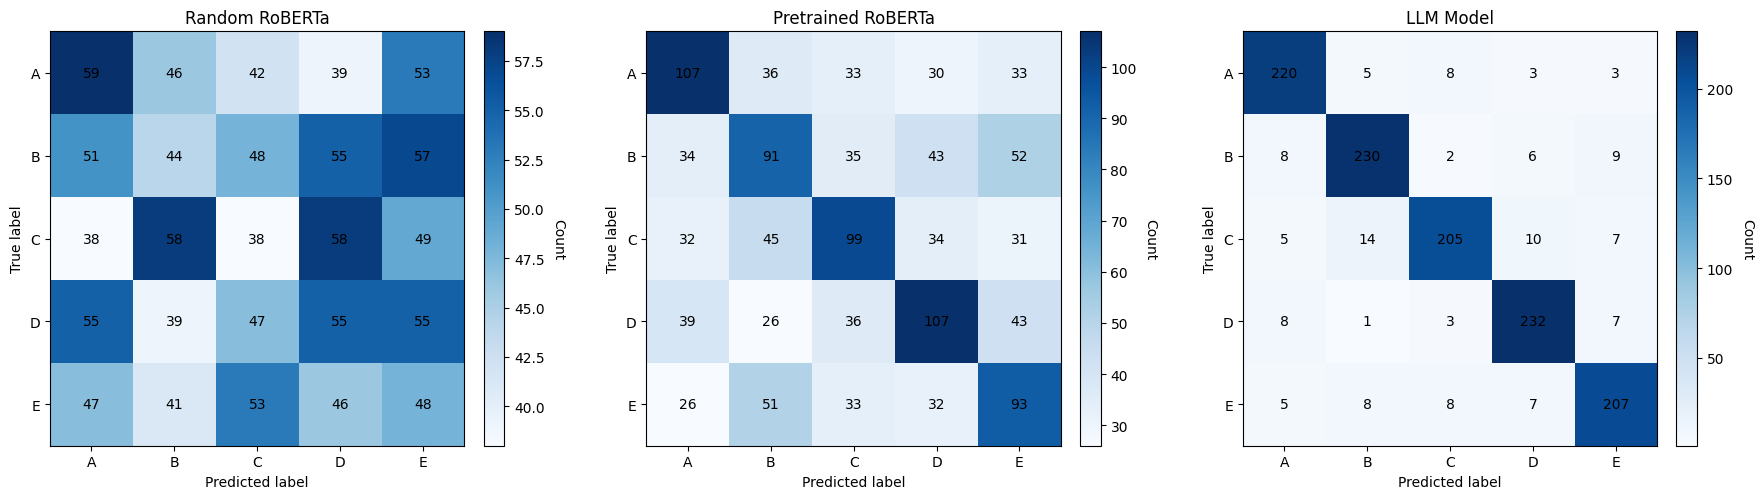

In [32]:
plot_confusion_matrices(
    pred_label_pairs=[
        (random_preds, random_labels),
        (pretrained_preds, pretrained_labels),
        (llm_predictions, llm_labels)
    ],
    titles=["Random RoBERTa", "Pretrained RoBERTa", "LLM Model"]
)

## Error Analysis

For the error analysis we have a look at the output of the llm model.

In order to analyse the output better, I created a function to generate a pandas Dataframe from the output.

In [33]:
def create_evaluation_dataframe(predictions, labels, questions, choices):
    df = pd.DataFrame({
        'Question': questions,
        'Choices': choices,
        'Predicted_Answer': predictions,
        'True_Label': labels
    })
    
    df['Is_Correct'] = df['Predicted_Answer'] == df['True_Label']
    
    return df


results_df = create_evaluation_dataframe(llm_predictions, llm_labels, questions, choices)

results_df.head()

,Question,Choices,Predicted_Answer,True_Label,Is_Correct
0,A revolving door is convenient for two directi...,"[bank, library, department store, mall, new york]",A,A,True
1,What do people aim to do at work?,"[complete job, learn from each other, kill ani...",A,A,True
2,Where would you find magazines along side many...,"[doctor, bookstore, market, train station, mor...",B,B,True
3,Where are you likely to find a hamburger?,"[fast food restaurant, pizza, ground up dead c...",A,A,True
4,James was looking for a good place to buy farm...,"[midwest, countryside, estate, farming areas, ...",A,A,True


We can verify that the model only generates valid output which is very impressive for a LLM.

In [34]:
results_df['Predicted_Answer'].value_counts()

Predicted_Answer
B    258
D    258
A    246
E    233
C    226
Name: count, dtype: int64

In the following example, we can see that there is twice the same choice which is a clear explanation why the model could predict the wrong Answer.

In [35]:
error_sample = results_df[~results_df["Is_Correct"]].loc[22]

print(f'Question: {error_sample['Question']}')
print(f'Choices: {error_sample['Choices']}')
print(f'Predicted Answer: {error_sample['Predicted_Answer']}')
print(f'True Label: {error_sample['True_Label']}')


Question: Though the thin film seemed fragile, for it's intended purpose it was actually nearly what?
Choices: ['indestructible', 'durable', 'undestroyable', 'indestructible', 'unbreakable']
Predicted Answer: A
True Label: D


# Interpretation

## Expectations

After reviewing the results from Project 1, my expectations for this project were significantly lowered.
- I anticipated that the randomly initialized transformer model would achieve around 30% accuracy, while the pretrained transformer might reach approximately 40%.
- I hoped the large language model (LLM) could attain about 80% accuracy.
- I expected that achieving meaningful performance would require extensive prompt engineering.

Given these expectations, I was genuinely surprised by the strong performance of both the pretrained transformer and the LLM. I also did not expect the LLM to follow instructions so reliably and with such minimal difficulty.

## Architectures

### RNN vs. Transformer

Compared to Project 2, RNN-based architectures showed better learning potential on smaller datasets. However, they struggled with capturing long-range dependencies, which limited their overall performance. 

This is where the pretrained transformer models proved advantageous, offering significantly improved results due to their ability to model global context effectively.

### BERT vs. RoBERTa

I initially experimented with BERT, but after several trials and further research, I found that RoBERTa consistently outperforms BERT across most NLP benchmarks. 

As a result, I chose RoBERTa for its enhanced training strategy and superior performance in downstream tasks.

## Speculations

It's likely that both transformer models (especially the randomly initialized one) could have achieved better performance with more training data.

As for the LLM, there was limited room for further improvement. Some questions in the dataset contain misleading answer choices (e.g., duplicate options), making it difficult or even impossible to select the correct answer consistently.

## Summary

This project gave me practical experience in working with NLP tasks and provided a valuable overview of different model architectures and their strengths. 

Since I hadn't taken the MLOps course yet, I also learned a great deal about experiment tracking and general model management through hands-on experimentation.

# Tools Used

- **Github Copilot**
- **Claude AI**
- **Chat-GPT**
- **Wandb**
- **HuggingFace**